In [ ]:
from qiskit import QuantumCircuit, transpile
# from qiskit.providers.basic_provider import BasicProvider
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [3]:
epr_circuit = QuantumCircuit(2, 2)
epr_circuit.h(0)
epr_circuit.cx(0, 1)
epr_circuit.measure([0, 1], [0, 1])

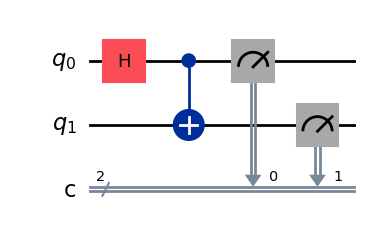

In [4]:
epr_circuit.draw("mpl")

In [5]:
singlet_circuit = QuantumCircuit(2, 2)
singlet_circuit.h(0)
singlet_circuit.x(1)
singlet_circuit.cx(0, 1)
singlet_circuit.measure([0, 1], [0, 1])

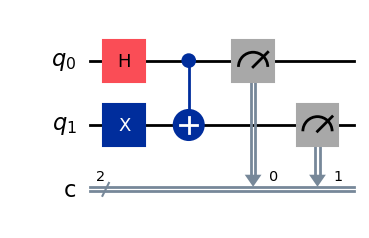

In [6]:
singlet_circuit.draw("mpl")

In [8]:
ghz_circuit = QuantumCircuit(3, 3)
ghz_circuit.h(0)
ghz_circuit.cx([0, 0], [1, 2])
ghz_circuit.measure([0, 1, 2], [0, 1, 2])

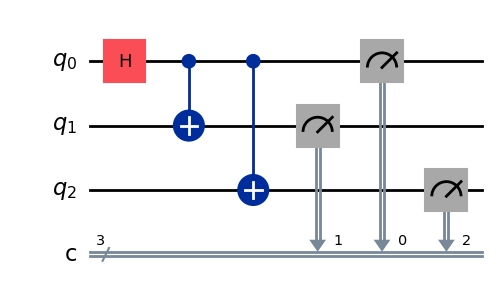

In [9]:
ghz_circuit.draw("mpl")

In [10]:
# simulator = BasicProvider().get_backend('basic_simulator')
simulator = AerSimulator()

In [11]:
compiled_epr_circuit = transpile(epr_circuit, simulator)
epr_circuit_job = simulator.run(compiled_epr_circuit, shots=1024)
epr_circuit_simulation_result = epr_circuit_job.result()
epr_circuit_simulation_result.get_counts()

{'11': 506, '00': 518}

In [11]:
epr_circuit_simulation_result

Result(backend_name='basic_simulator', backend_version='0.1', job_id='639b6df3-2972-4c75-977c-94476fc4e105', success=True, results=[ExperimentResult(shots=1024, success=True, meas_level=2, data=ExperimentResultData(counts={'0x3': 519, '0x0': 505}, memory=['0x3', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x3', '0x0', '0x0', '0x0', '0x3', '0x3', '0x3', '0x0', '0x0', '0x3', '0x3', '0x3', '0x0', '0x3', '0x0', '0x3', '0x0', '0x0', '0x0', '0x3', '0x0', '0x3', '0x0', '0x3', '0x0', '0x3', '0x3', '0x3', '0x0', '0x3', '0x3', '0x3', '0x0', '0x3', '0x3', '0x0', '0x3', '0x3', '0x0', '0x0', '0x0', '0x0', '0x3', '0x3', '0x0', '0x0', '0x0', '0x3', '0x3', '0x3', '0x0', '0x3', '0x3', '0x0', '0x3', '0x3', '0x0', '0x0', '0x0', '0x3', '0x0', '0x0', '0x0', '0x0', '0x3', '0x0', '0x0', '0x3', '0x3', '0x3', '0x0', '0x3', '0x0', '0x3', '0x3', '0x3', '0x3', '0x0', '0x0', '0x3', '0x3', '0x0', '0x0', '0x0', '0x3', '0x0', '0x0', '0x0', '0x3', '0x0', '0x0', '0x3', '0x0', '0x0', '0x0', '0x3', '0x3', '0x3', '0x3', '0

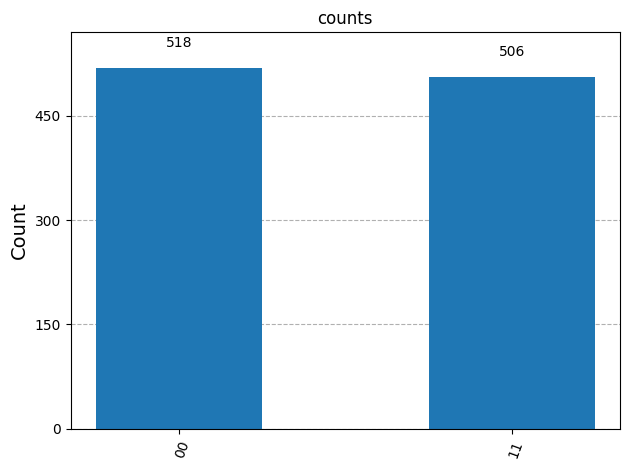

In [16]:
plot_histogram(epr_circuit_simulation_result.get_counts(), title='counts')

In [18]:
compiled_singlet_circuit = transpile(singlet_circuit, simulator)
singlet_circuit_job = simulator.run(compiled_singlet_circuit, shot=1024)
singlet_circuit_results = singlet_circuit_job.result()

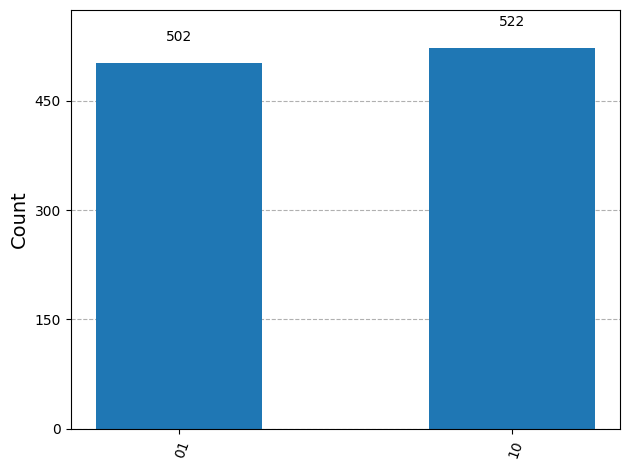

In [19]:
plot_histogram(singlet_circuit_results.get_counts())

In [21]:
compiled_ghz_circuit = transpile(ghz_circuit, simulator)
ghz_circuit_job = simulator.run(compiled_ghz_circuit, shot=1024)
ghz_circuit_results = ghz_circuit_job.result()

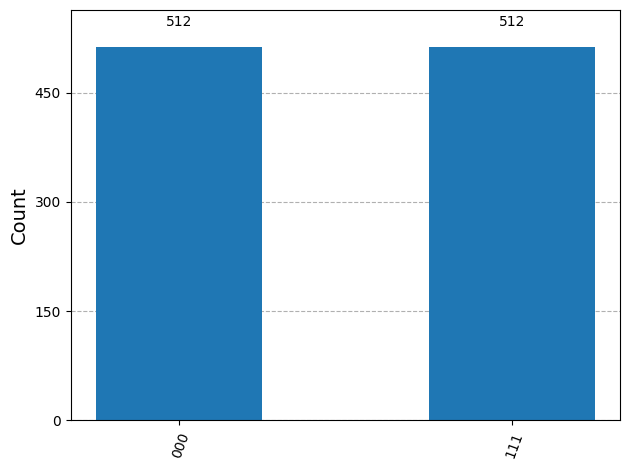

In [22]:
plot_histogram(ghz_circuit_results.get_counts())